# LightGBM Classification: 3s / 25 Segments, augmented

This notebook trains and evaluates a LightGBM classifier using MFCC mean and standard deviation features extracted from 25 random 3-second segments per track.

The model is trained on the training set, monitored on the validation set using early stopping, and finally evaluated on the test set. Since multiple segment-level predictions belong to one track, track-level aggregation is performed using mean class probabilities.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from src.config import (
    MFCC_MEAN_TRAIN_PKL,
    MFCC_MEAN_VAL_PKL,
    MFCC_MEAN_TEST_PKL,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)

from src.model_functions import prepare_features_labels

In [ ]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================

MODEL_NAME = "LightGBM_3s_25_aug"

# Target column in the MFCC mean feature files
TARGET_COL = "genre"

# Feature preparation settings
NORMALIZE_FEATURES = True
REDUCTION_FACTOR = 1.0

# LightGBM parameters
LEARNING_RATE = 0.03
NUM_LEAVES = 31
NUM_BOOST_ROUND = 100
EARLY_STOPPING_ROUNDS = 10
VERBOSE = -1

## Load MFCC mean feature datasets

The preprocessed MFCC mean feature datasets are loaded from the configured split directory. These datasets contain one row per sampled audio segment and are used as tabular input features for LightGBM.

In [ ]:
# Read in pkl-Files which contain means of mfccs
df_features_tracks_train = pd.read_pickle(MFCC_MEAN_TRAIN_PKL)
df_features_tracks_val = pd.read_pickle(MFCC_MEAN_VAL_PKL)
df_features_tracks_test = pd.read_pickle(MFCC_MEAN_TEST_PKL)

## Prepare features and labels

MFCC mean and standard deviation columns are selected as input features. The target labels are extracted from the genre column. Feature normalization is applied using the training data only.

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = prepare_features_labels(
    df_features_tracks_train,
    df_features_tracks_val,
    df_features_tracks_test,
    target_col=TARGET_COL,
    normalize_features=NORMALIZE_FEATURES,
    reduction_factor=REDUCTION_FACTOR,
    random_state=RANDOM_STATE
)

## Encode labels

LightGBM requires integer-encoded class labels for multiclass classification. The label encoder is fitted on the training labels and then applied to the validation and test labels.

In [ ]:
# Create LabelEncoder instance
# This will convert string class labels into integers
# Example: "Rock" → 0, "Jazz" → 1, etc.
le = LabelEncoder()

# Fit encoder on training labels and transform
# IMPORTANT:
# - fit_transform() learns the mapping from training data
# - and converts the labels into integer form
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

## Train LightGBM model

The model is trained on the training set. Early stopping is based on the validation set, while the test set is kept separate for final evaluation.

In [ ]:
# Create LightGBM Dataset for training
# - X_train: feature matrix (NumPy array or pandas DataFrame)
# - y_train_enc: integer-encoded labels
train_data = lgb.Dataset(
    X_train,
    label=y_train_enc
)

# Create LightGBM Dataset for testing
# - X_val: feature matrix for evaluation
# - y_val_enc: integer-encoded validation labels
# - reference=train_data:
#   This allows LightGBM to reuse some internal structures from the training dataset (improves efficiency and consistency)
val_data = lgb.Dataset(
    X_val,
    label=y_val_enc,
    reference=train_data
)

In [ ]:
# ---------------------------------------------------
# DEFINE LIGHTGBM PARAMETERS
# ---------------------------------------------------
params = {
    'objective': 'multiclass',          # Multi-class classification task
    'num_class': len(le.classes_),      # Number of unique classes (genres)
    'metric': 'multi_logloss',          # Metric for evaluation (log loss for multi-class)
    'learning_rate': LEARNING_RATE,              # Step size shrinkage
    'num_leaves': NUM_LEAVES,                   # Maximum number of leaves per tree (controls model complexity)
    'verbose': VERBOSE                     
}

# Define callbacks for training
callbacks = [
    lgb.early_stopping(stopping_rounds=10),   # Stop training if validation score doesn't improve for 10 rounds
    lgb.log_evaluation(period=10)             # Print evaluation results every 10 rounds
]

In [ ]:
# ---------------------------------------------------
# TRAIN LIGHTGBM MODEL
# ---------------------------------------------------
model = lgb.train(
    params,                    # Use the parameters defined above
    train_data,                # Training dataset
    valid_sets=[val_data],    # Validation dataset for early stopping
    num_boost_round=NUM_BOOST_ROUND,       # Maximum number of boosting iterations
    callbacks=callbacks        # Callbacks for early stopping and logging
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10200
[LightGBM] [Info] Number of data points in the train set: 85400, number of used features: 40
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
Training until validation scores don't improve for 10 rounds
[10]	valid_0's multi_logloss: 2.07307
[20]	valid_0's multi_logloss: 2.06678
[30]	valid_0's multi_logloss: 2.06057
[40]	valid_0's multi_logloss: 2.05443
[50]	valid_0's multi_logloss: 2.04839
[60]	valid_0's multi_loglos

Validation Accuracy: 0.5436792452830189
Validation Classification Report:                      precision    recall  f1-score   support

          Classical       0.62      0.80      0.70      1325
         Electronic       0.38      0.37      0.37      1325
               Folk       0.51      0.43      0.47      1325
            Hip-Hop       0.53      0.64      0.58      1325
               Jazz       0.47      0.39      0.43      1325
Old-Time / Historic       0.91      0.87      0.89      1325
                Pop       0.31      0.22      0.26      1325
               Rock       0.53      0.64      0.58      1325

           accuracy                           0.54     10600
          macro avg       0.53      0.54      0.53     10600
       weighted avg       0.53      0.54      0.53     10600



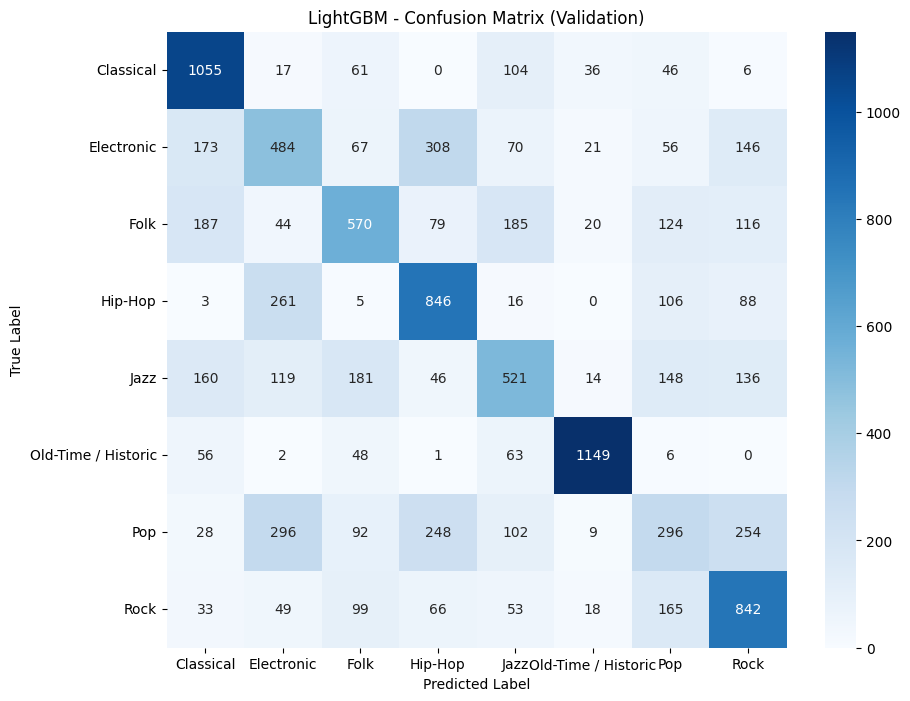

In [ ]:
# ---------------------------------------------------
# VALIDATION EVALUATION
# ---------------------------------------------------

# LightGBM predicts probabilities for each class
y_pred_prob = model.predict(X_val)  

# Convert probabilities → predicted class indices
y_pred_classes_idx = [np.argmax(p) for p in y_pred_prob]  

# Convert integer indices back to original string labels
y_pred_classes = le.inverse_transform(y_pred_classes_idx)  

# Compute accuracy
acc = accuracy_score(y_val, y_pred_classes)
print("Validation Accuracy:", acc)

# Detailed classification report (precision, recall, F1)
print("Validation Classification Report:", classification_report(y_val, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LightGBM - Confusion Matrix (Validation)")
plt.show()

Test Accuracy: 0.5393396226415095
Test Classification Report:                      precision    recall  f1-score   support

          Classical       0.61      0.78      0.68      1325
         Electronic       0.37      0.42      0.39      1325
               Folk       0.53      0.47      0.50      1325
            Hip-Hop       0.62      0.55      0.59      1325
               Jazz       0.42      0.34      0.38      1325
Old-Time / Historic       0.93      0.94      0.93      1325
                Pop       0.27      0.22      0.24      1325
               Rock       0.51      0.60      0.55      1325

           accuracy                           0.54     10600
          macro avg       0.53      0.54      0.53     10600
       weighted avg       0.53      0.54      0.53     10600



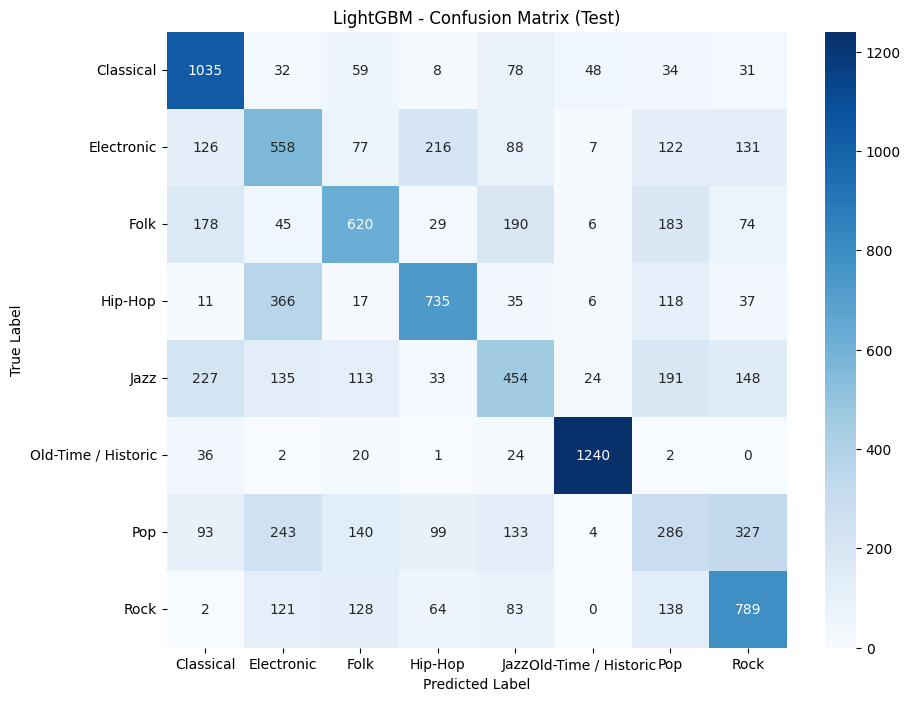

In [ ]:
# ---------------------------------------------------
# TEST EVALUATION
# ---------------------------------------------------

# LightGBM predicts probabilities for each class
y_pred_prob = model.predict(X_test)  

# Convert probabilities → predicted class indices
y_pred_classes_idx = [np.argmax(p) for p in y_pred_prob]  

# Convert integer indices back to original string labels
y_pred_classes = le.inverse_transform(y_pred_classes_idx)  

# ---------------------------------------------------
# Evaluation metrics
# ---------------------------------------------------
# Compute accuracy
acc = accuracy_score(y_test, y_pred_classes)
print("Test Accuracy:", acc)

# Detailed classification report (precision, recall, F1)
print("Test Classification Report:", classification_report(y_test, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LightGBM - Confusion Matrix (Test)")
plt.show()

In [ ]:
# ---------------------------------------------------------
# IDENTIFY MISCLASSIFIED TEST SAMPLES
# ---------------------------------------------------------

# LightGBM's predict method returns probabilities for each class
y_pred_probs = model.predict(X_test)  
# Convert predicted probabilities to class indices
# np.argmax selects the class with the highest probability
y_pred_indices = np.argmax(y_pred_probs, axis=1)  
# True labels are already class indices
y_true_indices = np.array(y_test)

# Create a DataFrame for analysis
# Make a copy of the test DataFrame to preserve original data
analysis_df = df_features_tracks_test.copy()
# True genres
analysis_df['true_genre'] = y_test.astype(str)
# Predicted genres using LabelEncoder
analysis_df['predicted_genre'] = le.inverse_transform(y_pred_indices)

# Identify misclassified samples
# Filter rows where prediction does not match the true label
misclassified = analysis_df[analysis_df['true_genre'] != analysis_df['predicted_genre']]

# Print misclassified samples for inspection
print(misclassified[['track_id', 'true_genre', 'predicted_genre']])

      track_id true_genre predicted_genre
77      050906  Classical             Pop
80      050906  Classical            Folk
87      050906  Classical            Jazz
90      050906  Classical            Folk
97      050906  Classical            Folk
...        ...        ...             ...
10590   001287       Rock      Electronic
10591   001287       Rock         Hip-Hop
10593   001287       Rock      Electronic
10594   001287       Rock         Hip-Hop
10596   001287       Rock         Hip-Hop

[4883 rows x 3 columns]



=== SEGMENT-LEVEL TEST EVALUATION ===
Accuracy: 0.5393396226415095
Macro-F1: 0.5322503595105172

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.61      0.78      0.68      1325
         Electronic       0.37      0.42      0.39      1325
               Folk       0.53      0.47      0.50      1325
            Hip-Hop       0.62      0.55      0.59      1325
               Jazz       0.42      0.34      0.38      1325
Old-Time / Historic       0.93      0.94      0.93      1325
                Pop       0.27      0.22      0.24      1325
               Rock       0.51      0.60      0.55      1325

           accuracy                           0.54     10600
          macro avg       0.53      0.54      0.53     10600
       weighted avg       0.53      0.54      0.53     10600


=== TRACK-LEVEL TEST EVALUATION: MAJORITY VOTING ===
Accuracy: 0.6037735849056604
Macro-F1: 0.5911816226887828

Classification Report:
        

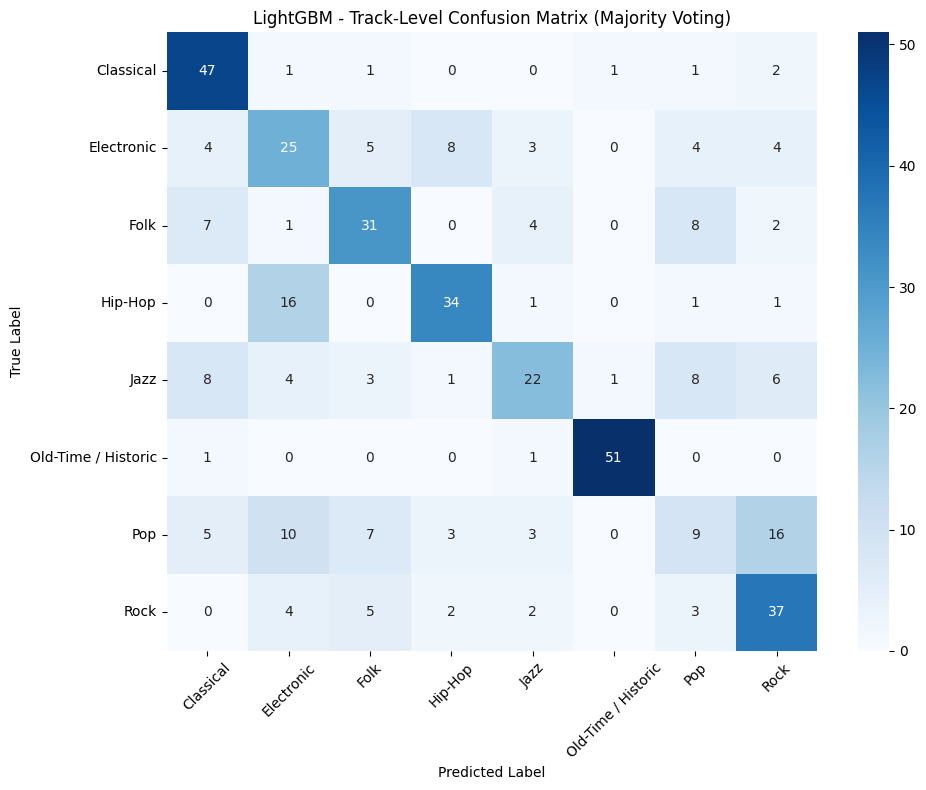


=== TRACK-LEVEL TEST EVALUATION: MEAN PROBABILITY ===
Accuracy: 0.6108490566037735
Macro-F1: 0.5991519798721543

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.64      0.89      0.74        53
         Electronic       0.43      0.47      0.45        53
               Folk       0.61      0.58      0.60        53
            Hip-Hop       0.72      0.64      0.68        53
               Jazz       0.60      0.47      0.53        53
Old-Time / Historic       0.96      0.98      0.97        53
                Pop       0.29      0.19      0.23        53
               Rock       0.55      0.66      0.60        53

           accuracy                           0.61       424
          macro avg       0.60      0.61      0.60       424
       weighted avg       0.60      0.61      0.60       424



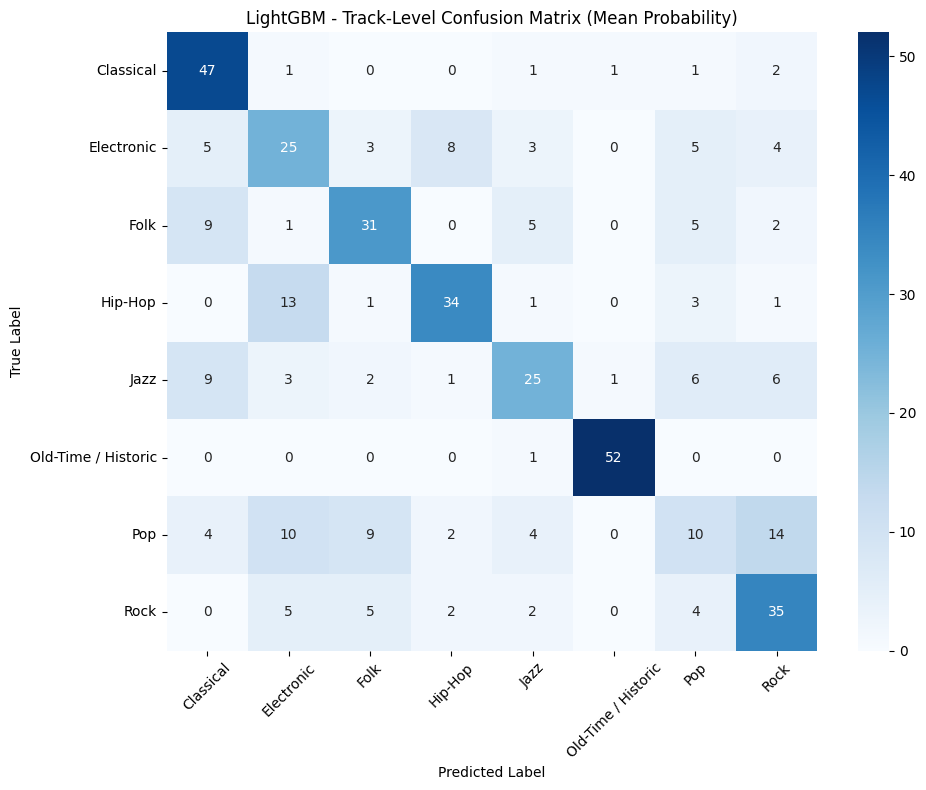


Saved segment- and track-level result CSV files to:
J:/Documents/FH/Git Repo Processing/MA_FMA_Dataprocessing/Models_final/Results


In [ ]:
# ---------------------------------------------------------
# TRACK-LEVEL EVALUATION (TEST SET)
# ---------------------------------------------------------
# The model was trained and evaluated on 3-second segments.
# For a track-level evaluation, all segment predictions belonging to the same
# track_id are aggregated into one final prediction per track.


# Build a metadata DataFrame that has the same row order as X_test / y_test
# This is required so every segment prediction can be assigned to its original track.
test_meta_df = df_features_tracks_test[df_features_tracks_test["genre"].notna()].reset_index(drop=True).copy()

# Safety check: X_test, y_test and metadata must have the same number of rows
assert len(test_meta_df) == len(y_test) == len(X_test), (
    f"Length mismatch: metadata={len(test_meta_df)}, y_test={len(y_test)}, X_test={len(X_test)}"
)

# Segment-level predictions and probabilities
test_pred_proba = model.predict(X_test)
segment_pred_labels = le.inverse_transform(np.argmax(test_pred_proba, axis=1))
class_names = list(le.classes_)

# Store segment-level prediction details in one DataFrame
segment_analysis_df = test_meta_df[["track_id", "genre"]].copy()
segment_analysis_df["true_genre"] = np.array(y_test).astype(str)
segment_analysis_df["predicted_genre"] = np.array(segment_pred_labels).astype(str)

# Add one probability column per class
for class_idx, class_name in enumerate(class_names):
    segment_analysis_df[f"prob_{class_name}"] = test_pred_proba[:, class_idx]

# ---------------------------------------------------------
# SEGMENT-LEVEL METRICS
# ---------------------------------------------------------
print("\n=== SEGMENT-LEVEL TEST EVALUATION ===")
print("Accuracy:", accuracy_score(segment_analysis_df["true_genre"], segment_analysis_df["predicted_genre"]))
print("Macro-F1:", f1_score(segment_analysis_df["true_genre"], segment_analysis_df["predicted_genre"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    segment_analysis_df["true_genre"],
    segment_analysis_df["predicted_genre"],
    labels=class_names,
    target_names=class_names
))

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION: MAJORITY VOTING
# ---------------------------------------------------------
track_majority_df = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"])["predicted_genre"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"predicted_genre": "predicted_genre_majority"})
)

print("\n=== TRACK-LEVEL TEST EVALUATION: MAJORITY VOTING ===")
print("Accuracy:", accuracy_score(track_majority_df["true_genre"], track_majority_df["predicted_genre_majority"]))
print("Macro-F1:", f1_score(track_majority_df["true_genre"], track_majority_df["predicted_genre_majority"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    track_majority_df["true_genre"],
    track_majority_df["predicted_genre_majority"],
    labels=class_names,
    target_names=class_names
))

cm_majority = confusion_matrix(
    track_majority_df["true_genre"],
    track_majority_df["predicted_genre_majority"],
    labels=class_names
)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_majority, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LightGBM - Track-Level Confusion Matrix (Majority Voting)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION: MEAN PROBABILITY
# ---------------------------------------------------------
prob_cols = [f"prob_{class_name}" for class_name in class_names]

track_probability_df = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"])[prob_cols]
    .mean()
    .reset_index()
)

# Select the class with the highest mean probability as final track prediction
mean_prob_values = track_probability_df[prob_cols].to_numpy()
track_probability_df["predicted_genre_mean_probability"] = [
    class_names[idx] for idx in np.argmax(mean_prob_values, axis=1)
]

print("\n=== TRACK-LEVEL TEST EVALUATION: MEAN PROBABILITY ===")
print("Accuracy:", accuracy_score(track_probability_df["true_genre"], track_probability_df["predicted_genre_mean_probability"]))
print("Macro-F1:", f1_score(track_probability_df["true_genre"], track_probability_df["predicted_genre_mean_probability"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    track_probability_df["true_genre"],
    track_probability_df["predicted_genre_mean_probability"],
    labels=class_names,
    target_names=class_names
))

cm_mean_probability = confusion_matrix(
    track_probability_df["true_genre"],
    track_probability_df["predicted_genre_mean_probability"],
    labels=class_names
)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mean_probability, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LightGBM - Track-Level Confusion Matrix (Mean Probability)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# SAVE TRACK-LEVEL RESULTS
# ---------------------------------------------------------
# Store segment-level and track-level results for later error analysis.
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Segment-level misclassifications.
segment_misclassified = segment_analysis_df[
    segment_analysis_df["true_genre"] != segment_analysis_df["predicted_genre"]
]

segment_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_segments.csv",
    index=False
)

# Track-level predictions: Majority Voting.
track_majority_export = track_majority_df.rename(
    columns={"predicted_genre_majority": "predicted_genre"}
)

track_majority_export[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_majority.csv",
    index=False
)

# Track-level predictions: Mean Probability.
track_probability_export = track_probability_df.rename(
    columns={"predicted_genre_mean_probability": "predicted_genre"}
)

track_probability_export[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_mean_probability.csv",
    index=False
)

# Track-level misclassifications: Majority Voting.
track_majority_misclassified = track_majority_export[
    track_majority_export["true_genre"] != track_majority_export["predicted_genre"]
]

track_majority_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_majority.csv",
    index=False
)

# Track-level misclassifications: Mean Probability.
track_probability_misclassified = track_probability_export[
    track_probability_export["true_genre"] != track_probability_export["predicted_genre"]
]

track_probability_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_mean_probability.csv",
    index=False
)

print("\nSaved segment- and track-level result CSV files to:")
print(MODEL_RESULTS_DIR)